<a href="https://www.kaggle.com/code/navneet0094/dogvscats?scriptVersionId=314360327" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00985-127787239.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00667-3846168829.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00891-3846169053.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00528-3846168690.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00689-3846168851.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00593-3846168755.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00894-3846169056.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00622-3846168784.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00907-3846169069.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00983-127787237.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00817-3846168979.png
/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00576-3846168738.png
/kaggl

In [5]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout
import warnings
warnings.filterwarnings('ignore')


2026-04-25 13:26:26.179655: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777123586.379686      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777123586.443117      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777123586.898818      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777123586.898853      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777123586.898856      55 computation_placer.cc:177] computation placer alr

In [6]:
train_ds = keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256),
    validation_split=0.2,
    subset='training',
    seed=123
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256),
    validation_split=0.2,
    subset='validation',
    seed=123
)

Found 1000 files belonging to 2 classes.
Using 800 files for training.


I0000 00:00:1777123612.126309      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777123612.132600      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1000 files belonging to 2 classes.
Using 200 files for validation.


In [7]:
def process(image,label):
  image=tf.cast(image/255. ,tf.float32)
  return image,label
    
train_ds=train_ds.map(process)
validation_ds=validation_ds.map(process)

In [8]:
# training cnn model

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [10]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [11]:
history=model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10


I0000 00:00:1777123617.909425     132 service.cc:152] XLA service 0x7810240121b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777123617.909480     132 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777123617.909486     132 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777123618.772730     132 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-25 13:27:02.374069: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 13:27:02.682199: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 1/25 ━━━━━━━━━━━━━━━━━━━━ 4:50 12s/step - accuracy: 0.5000 - loss: 1.0050

I0000 00:00:1777123626.908714     132 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 238ms/step - accuracy: 0.6455 - loss: 5.9299 - val_accuracy: 0.5450 - val_loss: 2.2111
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - accuracy: 0.8452 - loss: 1.0006 - val_accuracy: 0.5650 - val_loss: 6.5993
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.8896 - loss: 0.4917 - val_accuracy: 0.5650 - val_loss: 9.5514
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - accuracy: 0.9159 - loss: 0.7815 - val_accuracy: 0.5700 - val_loss: 7.7880
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - accuracy: 0.9616 - loss: 0.3726 - val_accuracy: 0.5950 - val_loss: 5.4272
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.9562 - loss: 0.2713 - val_accuracy: 0.5750 - val_loss: 10.3068
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - accuracy: 0.9771 - loss: 0.1162 - val_accuracy: 0.7000 - val_loss: 1.7155
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.9860 - loss: 0.1286 - val_accuracy: 0.5750 - va

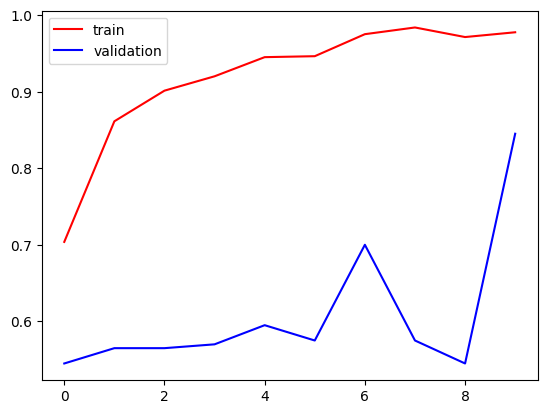

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

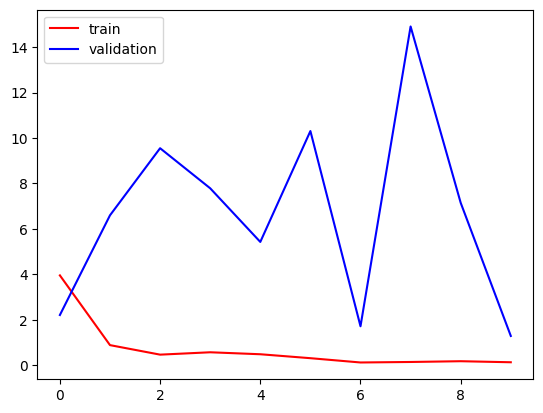

In [13]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [14]:

# ways to reduce overfitting

# Add more data
# Data Augmentation -> next video
# L1/L2 Regularizer
# Dropout
# Batch Norm
# Reduce complexity

In [15]:
import cv2

In [16]:

test_img=cv2.imread('/kaggle/input/datasets/navneet0094/cat-img/cat.jpeg')

In [17]:
test_img.shape

(148, 225, 3)

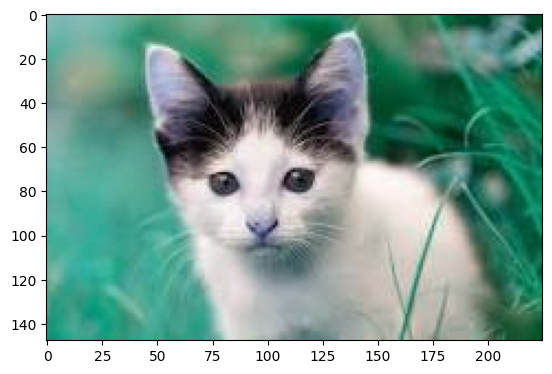

In [18]:

plt.imshow(test_img)

In [19]:

test_img=cv2.resize(test_img,(256,256))

In [20]:
test_img.shape

(256, 256, 3)

In [21]:
test_input=test_img.reshape((1,256,256,3))

In [22]:

model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 969ms/step


array([[0.]], dtype=float32)

In [36]:

from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [38]:
img=image.load_img("/kaggle/input/datasets/navneet0094/cat-img/cat.jpeg",target_size=(200,200))

In [39]:
type(img)

PIL.Image.Image

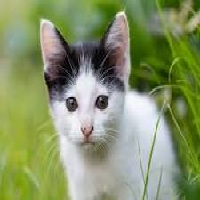

In [40]:
img

In [41]:
datagen=ImageDataGenerator(
    rotation_range=30,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
)
    

In [43]:
img=image.img_to_array(img)

In [44]:
img.shape

(200, 200, 3)

In [45]:
input_batch=img.reshape(1,200,200,3)

In [48]:
import os

os.makedirs('/kaggle/working/aug', exist_ok=True)

In [49]:
i=0

for output in datagen.flow(input_batch,batch_size=1,save_to_dir='/kaggle/working/aug'):
  i=i+1
  if i==10:
    break

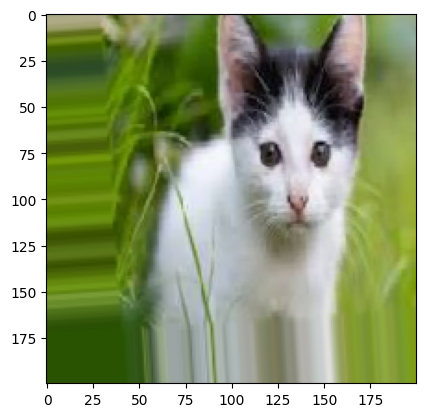

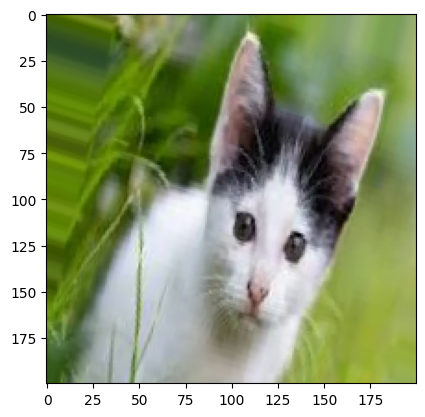

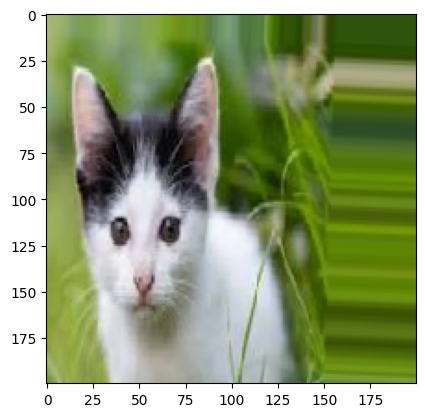

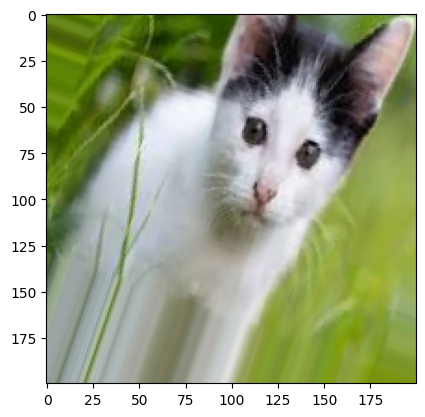

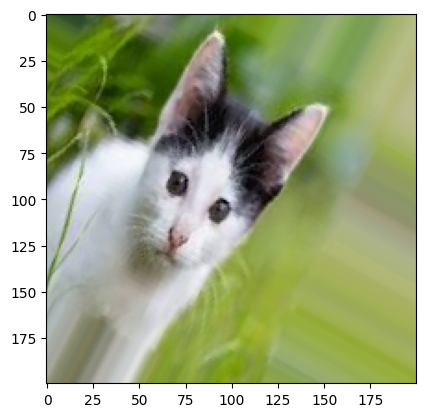

In [57]:
import matplotlib.pyplot as plt
folder = '/kaggle/working/aug'

for img_name in os.listdir(folder)[:5]:
    img = cv2.imread(os.path.join(folder, img_name))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    # plt.imshow(img)
    plt.show()